# Business Problem

Effective inventory and sales management are critical for optimizing
profitability in the retail and wholesale industry. Companies need to ensure
that they are not incurring losses due to inefficient pricing, poor inventory
turnover, or vendor dependency. The goal of this analysis is to:
- Identify underperforming brands that require promotional or pricing
adjustments.
- Determine top vendors contributing to sales and gross profit.
- Analyze the impact of bulk purchasing on unit costs.
- Assess inventory turnover to reduce holding costs and improve
efficiency.
- Investigate the profitability variance between high-performing and
low-performing vendors.

# Loading dataset

In [3]:
import time
import os
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import sqlite3

In [3]:
engine = create_engine('sqlite:///inventory.db')
path = r"D:\Data analytics\Dataset\Vendor Performance dataset"
start_time = time.time()

for file in os.listdir(path):
    if file.endswith('.csv'):
        table_name = file[:-4].lower().replace(" ", "_")
        file_path = os.path.join(path, file)
        
        # We use a 'chunksize' in read_csv to avoid loading the whole file into RAM
        # This creates a 'TextFileReader' object (an iterator)
        reader = pd.read_csv(file_path, chunksize=100000)
        
        first_chunk = True
        for chunk in reader:
            # For the first chunk, we 'replace' the table.
            # For every chunk after, we 'append' to the existing table.
            if_exists_val = 'replace' if first_chunk else 'append'
            
            chunk.to_sql(table_name, con=engine, if_exists=if_exists_val, index=False)
            first_chunk = False
            
        print(f"Successfully ingested: {table_name}")

end_time = time.time()
print(f"Total Time taken: {round(end_time - start_time, 2)/60} minutes")

Successfully ingested: begin_inventory
Successfully ingested: end_inventory
Successfully ingested: purchases
Successfully ingested: purchase_prices
Successfully ingested: sales
Successfully ingested: vendor_invoice
Total Time taken: 951.59s


In [5]:
conn = sqlite3.connect("inventory.db")

tables = pd.read_sql_query('select name  from sqlite_master', conn)
tables

,name
0,begin_inventory
1,end_inventory
2,purchases
3,purchase_prices
4,sales
5,vendor_invoice
6,vendor_sales_summary


---
# Exploratory Data Analysis

Understanding the dataset to explore how the data is present in the database and if there is a need of creating some aggregated tables that can help with:
- Vendor selection for profitability
- Product Pricing Optimization

In [54]:
for table in tables['name']:
    print(table.center(100,"-"))
    print(pd.read_sql(f"select count(*) as No_of_records from {table}", conn))
    display(pd.read_sql(f"select * from {table} limit 5", conn))
    print("\n")

------------------------------------------begin_inventory-------------------------------------------
   No_of_records
0         206529


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01




-------------------------------------------end_inventory--------------------------------------------
   No_of_records
0         224489


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31




---------------------------------------------purchases----------------------------------------------
   No_of_records
0        2372474


...

,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2024-01-01,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
1,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,2,32.98,16.49,2024-01-02,750.0,1,1.57,12546,JIM BEAM BRANDS COMPANY
2,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2024-01-03,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
3,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,14.49,14.49,2024-01-08,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
4,1_HARDERSFIELD_1005,1,1005,Maker's Mark Combo Pack,375mL 2 Pk,2,69.98,34.99,2024-01-09,375.0,1,0.79,12546,JIM BEAM BRANDS COMPANY




-------------------------------------------vendor_invoice-------------------------------------------
   No_of_records
0           5543


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None




----------------------------------------vendor_sales_summary----------------------------------------
   No_of_records
0          10692


,VendorNumber,VendorName,Brand,Description,ActualPrice,Volume,TotalPurchasePrice,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesPrice,TotalSalesDollars,TotalExciseTax,AllocatedFreight,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,36.99,750.0,71.58,8,190.88,18.0,295.92,665.82,2.00,0.917979,474.94,0.713316,2.250000,3.488160
1,2,"IRA GOLDMAN AND WILLIAMS, LLP",90609,Flavor Essence Variety 5 Pak,24.99,162.5,170.00,320,5440.00,24.0,449.82,599.76,0.52,26.162021,-4840.24,-8.070295,0.075000,0.110250
2,54,AAPER ALCOHOL & CHEMICAL CO,990,Ethyl Alcohol 200 Proof,134.49,3750.0,105.07,1,105.07,0.0,0.00,0.00,0.00,0.480000,-105.07,0.000000,0.000000,0.000000
3,60,ADAMBA IMPORTS INTL INC,771,Bak's Krupnik Honey Liqueur,14.99,750.0,45.76,39,446.16,47.0,494.67,704.53,37.01,2.135889,258.37,0.366727,1.205128,1.579097
4,60,ADAMBA IMPORTS INTL INC,3401,Vesica Vodka,14.99,1750.0,11.10,6,66.60,0.0,0.00,0.00,0.00,0.318832,-66.60,0.000000,0.000000,0.000000


In [58]:
table_info = pd.read_sql("select name from sqlite_master",conn)
table_info

,name
0,begin_inventory
1,end_inventory
2,purchases
3,purchase_prices
4,sales
5,vendor_invoice
6,vendor_sales_summary


In [59]:
print("Table Records\n")
for table in table_info['name']:
    print(f"{table}:", pd.read_sql(f"select count(*)/1000 as count_in_K from {table}", conn)['count_in_K'].values[0],"K Rows")

Table Records

begin_inventory: 206 K Rows
end_inventory: 224 K Rows
purchases: 2372 K Rows
purchase_prices: 12 K Rows
sales: 12825 K Rows
vendor_invoice: 5 K Rows
vendor_sales_summary: 10 K Rows


In [61]:
print("Table Details\n")
for table in table_info['name']:
    print()
    print(table.center(120,"-"))
    display(pd.read_sql(f"select * from {table} limit 5", conn))

Table Details


----------------------------------------------------begin_inventory-----------------------------------------------------


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01



-----------------------------------------------------end_inventory------------------------------------------------------


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31



-------------------------------------------------------purchases--------------------------------------------------------


...

,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2024-01-01,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
1,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,2,32.98,16.49,2024-01-02,750.0,1,1.57,12546,JIM BEAM BRANDS COMPANY
2,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2024-01-03,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
3,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,14.49,14.49,2024-01-08,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
4,1_HARDERSFIELD_1005,1,1005,Maker's Mark Combo Pack,375mL 2 Pk,2,69.98,34.99,2024-01-09,375.0,1,0.79,12546,JIM BEAM BRANDS COMPANY



-----------------------------------------------------vendor_invoice-----------------------------------------------------


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None



--------------------------------------------------vendor_sales_summary--------------------------------------------------


,VendorNumber,VendorName,Brand,Description,ActualPrice,Volume,TotalPurchasePrice,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesPrice,TotalSalesDollars,TotalExciseTax,AllocatedFreight,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,36.99,750.0,71.58,8,190.88,18.0,295.92,665.82,2.00,0.917979,474.94,0.713316,2.250000,3.488160
1,2,"IRA GOLDMAN AND WILLIAMS, LLP",90609,Flavor Essence Variety 5 Pak,24.99,162.5,170.00,320,5440.00,24.0,449.82,599.76,0.52,26.162021,-4840.24,-8.070295,0.075000,0.110250
2,54,AAPER ALCOHOL & CHEMICAL CO,990,Ethyl Alcohol 200 Proof,134.49,3750.0,105.07,1,105.07,0.0,0.00,0.00,0.00,0.480000,-105.07,0.000000,0.000000,0.000000
3,60,ADAMBA IMPORTS INTL INC,771,Bak's Krupnik Honey Liqueur,14.99,750.0,45.76,39,446.16,47.0,494.67,704.53,37.01,2.135889,258.37,0.366727,1.205128,1.579097
4,60,ADAMBA IMPORTS INTL INC,3401,Vesica Vodka,14.99,1750.0,11.10,6,66.60,0.0,0.00,0.00,0.00,0.318832,-66.60,0.000000,0.000000,0.000000


- The `purchases` table contains actual purchase data, including the date of purchase, products details (brands) purchased by vendors, the amount paid (in dollars), and the quantity purchased. The combination of `Store` and '`PONumber` is unique in this table.
- The `PurchasePrice` column is derived from the purchase_prices table, which provides product-wise actual and purchase prices where `Brand` is unique in this table.
- The `vendor_invoice` table aggregates data from the `purchases` table, summarizing quantity and dollar amounts, along with an additional column for `freight`. This table maintains uniqueness based on vendor and PO number.
- The `sales` table captures actual sales transactions, detailing the brands purchased by vendors, the quantity sold, the `selling price`, and the revenue earned.


## Summary Table

As the data that we need for analysis is distributed in different tables, we need to create a summary table containing:
- purchase transactions made by vendors
- sales transaction data
- freight costs for each vendor
- actual product prices from vendors

**Purchase Summary**

In [62]:
purchase_summary = pd.read_sql('''select

p.VendorNumber,
p.VendorName,
p.Brand,
pp.Price As ActualPrice,
pp.Volume,
sum(p.PurchasePrice) as TotalPurchasePrice,
sum(Quantity) as TotalPurchaseQuantity,
sum(Dollars) as TotalPurchaseDollars

from purchases as p
join purchase_prices as pp
on p.Brand = pp.Brand
where Price > 0
group by p.VendorNumber, p.VendorName, p.Brand
order by TotalPurchasePrice desc

''', conn)

In [63]:
purchase_summary

,VendorNumber,VendorName,Brand,ActualPrice,Volume,TotalPurchasePrice,TotalPurchaseQuantity,TotalPurchaseDollars
0,1128,BROWN-FORMAN CORP,1233,36.99,1750,172961.68,145080,3811251.60
1,4425,MARTIGNETTI COMPANIES,3405,28.99,1750,150874.14,164038,3804041.22
2,3960,DIAGEO NORTH AMERICA INC,3545,29.99,1750,138476.14,138109,3023206.01
3,3960,DIAGEO NORTH AMERICA INC,8680,39.99,1750,137439.92,47546,1373128.48
4,17035,PERNOD RICARD USA,2589,39.99,1750,135220.96,70783,2177285.08
...,...,...,...,...,...,...,...,...
10687,7245,PROXIMO SPIRITS INC.,3065,0.99,50,0.71,1,0.71
10688,9552,M S WALKER INC,8151,0.99,50,0.71,8,5.68
10689,11567,CAMPARI AMERICA,3371,0.99,50,0.71,40,28.40
10690,10754,PERFECTA WINES,902,0.99,375,0.64,24,15.36


**Freight Cost**

In [16]:
## Freight Summary

freight_summary = pd.read_sql("select VendorNumber, VendorName, sum(Freight) as freight_cost from vendor_invoice group by VendorNumber", conn)
freight_summary

,VendorNumber,VendorName,freight_cost
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",27.08
1,54,AAPER ALCOHOL & CHEMICAL CO,0.48
2,60,ADAMBA IMPORTS INTL INC,367.52
3,105,ALTAMAR BRANDS LLC,62.39
4,200,AMERICAN SPIRITS EXCHANGE,6.19
...,...,...,...
121,98450,Serralles Usa LLC,856.02
122,99166,STARK BREWING COMPANY,130.09
123,172662,SWEETWATER FARM,178.34
124,173357,TAMWORTH DISTILLING,202.50


**Sales Summary**

In [19]:
# sales summary
import time
start = time.time()
sales_summary = pd.read_sql("""select
VendorNo,
Brand,
sum(SalesQuantity) as TotalSalesQuantity,
sum(SalesPrice) as TotalSalesPrice,
sum(SalesDollars) as TotalSalesDollars,
sum(ExciseTax) as TotalExciseTax
from sales
group by VendorNo, Brand
order by TotalSalesDollars desc""", conn)

end = time.time()
print("time taken:", (end-start)/60,"min")

time taken: 1.9599263350168863 min


In [23]:
sales_summary

,VendorNo,Brand,TotalSalesQuantity,TotalSalesPrice,TotalSalesDollars,TotalExciseTax
0,1128,1233,142049,672819.31,5101919.51,260999.20
1,4425,3405,160247,561512.37,4819073.49,294438.66
2,17035,8068,187140,461140.15,4538120.60,343854.07
3,3960,4261,200412,420050.01,4475972.88,368242.80
4,3960,3545,135838,545778.28,4223107.62,249587.83
...,...,...,...,...,...,...
11267,3252,3933,2,0.99,1.98,0.10
11268,3924,9123,2,0.99,1.98,0.10
11269,10050,3623,2,1.98,1.98,0.10
11270,9206,2773,1,0.99,0.99,0.05


**Final Table**

In [24]:
summary_tables = [purchase_summary,freight_summary,sales_summary]

for t in summary_tables:
    print()
    print(t.columns)


Index(['VendorNumber', 'VendorName', 'Brand', 'ActualPrice', 'Volume',
       'TotalPurchasePrice', 'TotalPurchaseQuantity', 'TotalPurchaseDollars'],
      dtype='str')

Index(['VendorNumber', 'VendorName', 'freight_cost'], dtype='str')

Index(['VendorNo', 'Brand', 'TotalSalesQuantity', 'TotalSalesPrice',
       'TotalSalesDollars', 'TotalExciseTax'],
      dtype='str')


In [ ]:
vendor_totals AS (
    SELECT 
        VendorNumber,
        SUM(TotalPurchaseDollars) AS VendorTotal
    FROM purchase_summary
    GROUP BY VendorNumber)

SELECT 
    ps.*,
    fs.freight_cost * (ps.TotalPurchaseDollars / vt.VendorTotal) AS AllocatedFreight

In [151]:
query = '''
WITH purchase_summary AS (
    SELECT 
        p.VendorNumber, 
        p.VendorName, 
        p.Brand, 
        p.Description,
        pp.Price AS ActualPrice, 
        pp.Volume,
        SUM(p.PurchasePrice) AS TotalPurchasePrice,
        SUM(p.Quantity) AS TotalPurchaseQuantity,
        SUM(p.Dollars) AS TotalPurchaseDollars
    FROM purchases AS p
    JOIN purchase_prices AS pp ON p.Brand = pp.Brand
    WHERE pp.Price > 0
    GROUP BY p.VendorNumber, p.VendorName, p.Brand
),

sales_summary AS (
    SELECT 
        VendorNo, Brand,
        SUM(SalesQuantity) AS TotalSalesQuantity,
        SUM(SalesPrice) AS TotalSalesPrice,
        SUM(SalesDollars) AS TotalSalesDollars,
        SUM(ExciseTax) AS TotalExciseTax
    FROM sales
    GROUP BY VendorNo, Brand
),

freight_summary AS (
    SELECT VendorNumber, VendorName, SUM(Freight) AS freight_cost 
    FROM vendor_invoice 
    GROUP BY VendorNumber
),

vendor_totals AS (
    SELECT 
        VendorNumber,
        SUM(TotalPurchaseDollars) AS VendorTotal
    FROM purchase_summary
    GROUP BY VendorNumber
)


SELECT 
    ps.*, 
    ss.TotalSalesQuantity, ss.TotalSalesPrice, ss.TotalSalesDollars, ss.TotalExciseTax,
    fs.freight_cost * (ps.TotalPurchaseDollars / vt.VendorTotal) AS AllocatedFreight
FROM purchase_summary AS ps
LEFT JOIN sales_summary AS ss ON ps.VendorNumber = ss.VendorNo AND ps.Brand = ss.Brand
LEFT JOIN freight_summary AS fs ON ps.VendorNumber = fs.VendorNumber
LEFT JOIN vendor_totals as vt ON ps.VendorNumber  = vt.VendorNumber 
'''

start_time = time.time()
vendor_performance_df = pd.read_sql(query, conn)
end_time = time.time()

print(f"Time Taken: {(end_time - start_time)/60:.4f} minutes")

Time Taken: 3.2116 minutes


This query generates a vendor-wise sales and purchase summary, which is valuable for:

Performance Optimization:
- The query involves heavy joins and aggregations on large datasets like sales and purchases.
- Dure to grain mismatch in joining feight summary table with the purchase summary table, Freight cost allocated proportional to purchase dollars, supported by strong correlation at vendor level.
- Storing the pre-aggregated results avoids repeated expensive computations.
- Helps in analyzing sales, purchases, and pricing for different vendors and brands.- Future Benefits of Storing this data for faster Dashboarding & Reporting.
- Instead of running expensive queries each time, dashboards can fetch data quickly from vendor_sales_summary.

**Cleaning**

In [153]:
vendor_performance_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10692 entries, 0 to 10691
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorNumber           10692 non-null  int64  
 1   VendorName             10692 non-null  str    
 2   Brand                  10692 non-null  int64  
 3   Description            10692 non-null  str    
 4   ActualPrice            10692 non-null  float64
 5   Volume                 10692 non-null  str    
 6   TotalPurchasePrice     10692 non-null  float64
 7   TotalPurchaseQuantity  10692 non-null  int64  
 8   TotalPurchaseDollars   10692 non-null  float64
 9   TotalSalesQuantity     10514 non-null  float64
 10  TotalSalesPrice        10514 non-null  float64
 11  TotalSalesDollars      10514 non-null  float64
 12  TotalExciseTax         10514 non-null  float64
 13  AllocatedFreight       10692 non-null  float64
dtypes: float64(8), int64(3), str(3)
memory usage: 1.1 MB


In [158]:
vendor_performance_df.isna().sum()

VendorNumber               0
VendorName                 0
Brand                      0
Description                0
ActualPrice                0
Volume                     0
TotalPurchasePrice         0
TotalPurchaseQuantity      0
TotalPurchaseDollars       0
TotalSalesQuantity       178
TotalSalesPrice          178
TotalSalesDollars        178
TotalExciseTax           178
AllocatedFreight           0
dtype: int64

In [159]:
vendor_performance_df.fillna(0, inplace = True)

,VendorNumber,VendorName,Brand,Description,ActualPrice,Volume,TotalPurchasePrice,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesPrice,TotalSalesDollars,TotalExciseTax,AllocatedFreight
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,36.99,750,71.58,8,190.88,18.0,295.92,665.82,2.00,0.917979
1,2,"IRA GOLDMAN AND WILLIAMS, LLP",90609,Flavor Essence Variety 5 Pak,24.99,162.5,170.00,320,5440.00,24.0,449.82,599.76,0.52,26.162021
2,54,AAPER ALCOHOL & CHEMICAL CO,990,Ethyl Alcohol 200 Proof,134.49,3750,105.07,1,105.07,0.0,0.00,0.00,0.00,0.480000
3,60,ADAMBA IMPORTS INTL INC,771,Bak's Krupnik Honey Liqueur,14.99,750,45.76,39,446.16,47.0,494.67,704.53,37.01,2.135889
4,60,ADAMBA IMPORTS INTL INC,3401,Vesica Vodka,14.99,1750,11.10,6,66.60,0.0,0.00,0.00,0.00,0.318832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10687,173357,TAMWORTH DISTILLING,2804,Camp Robber Whiskey,44.99,750,610.66,210,6749.40,140.0,3194.29,6298.60,110.33,33.305850
10688,173357,TAMWORTH DISTILLING,3666,Art in the Age Chicory Root,24.99,375,751.60,520,9770.80,360.0,4873.05,8996.40,141.19,48.215367
10689,173357,TAMWORTH DISTILLING,3848,Chicory Root Vodka,30.99,750,69.90,28,652.40,6.0,92.97,185.94,4.71,3.219358
10690,173357,TAMWORTH DISTILLING,3909,White Mountain Vodka,24.99,750,1762.67,1232,23863.84,982.0,14469.21,24540.18,773.87,117.759426


In [170]:
vendor_performance_df.duplicated().sum()

np.int64(0)

In [171]:
vendor_performance_df['VendorNumber'].unique()

array([     2,     54,     60,    105,    200,    287,    388,    480,
          516,    653,    660,   1003,   1128,   1189,   1265,   1273,
         1392,   1439,   1485,   1587,   1590,   1601,   1650,   1655,
         1703,   2000,   2242,   2396,   2450,   2496,   2555,   2561,
         2876,   3089,   3252,   3551,   3664,   3924,   3950,   3951,
         3960,   4380,   4425,   4466,   4550,   4692,   4848,   4901,
         4950,   5083,   5270,   5455,   5612,   5992,   6213,   6215,
         6280,   6355,   6359,   6785,   6830,   7153,   7154,   7239,
         7240,   7245,   7255,   7749,   8004,   8112,   8150,   8320,
         8352,   8663,   8664,   8673,   8735,   8892,   8920,   9099,
         9165,   9206,   9260,   9552,   9622,   9625,   9744,   9751,
         9815,   9819,  10000,  10050,  10754,  11567,  12331,  12546,
        17031,  17032,  17033,  17035,  17037,  28750,  28776,  90010,
        90011,  90017,  90024,  90026,  90027,  90032,  90033,  90037,
      

In [162]:
vender_performance_df['VendorName'].unique()

<StringArray>
['IRA GOLDMAN AND WILLIAMS, LLP',   'AAPER ALCOHOL & CHEMICAL CO',
       'ADAMBA IMPORTS INTL INC',            'ALTAMAR BRANDS LLC',
     'AMERICAN SPIRITS EXCHANGE',          'APPOLO VINEYARDS LLC',
    'ATLANTIC IMPORTING COMPANY',               'BACARDI USA INC',
           'BANFI PRODUCTS CORP',          'STATE WINE & SPIRITS',
 ...
               'INCREDIBREW INC',           'SWEET BABY VINEYARD',
       'WALPOLE MTN VIEW WINERY',             'ZORVINO VINEYARDS',
          'BLACK COVE BEVERAGES',             'Serralles Usa LLC',
         'STARK BREWING COMPANY',               'SWEETWATER FARM',
           'TAMWORTH DISTILLING',            'FLAVOR ESSENCE INC']
Length: 128, dtype: str

In [172]:
vendor_performance_df['VendorName']= vender_performance_df['VendorName'].str.strip()

In [183]:
vendor_performance_df['Brand']

0        90085
1        90609
2          990
3          771
4         3401
         ...  
10687     2804
10688     3666
10689     3848
10690     3909
10691    90609
Name: Brand, Length: 10692, dtype: int64

In [184]:
vendor_performance_df['Description'].nunique()

9651

In [185]:
vendor_performance_df['Volume'] = vendor_performance_df['Volume'].astype('float')

**New Columns**

In [186]:
vendor_performance_df.columns

Index(['VendorNumber', 'VendorName', 'Brand', 'Description', 'ActualPrice',
       'Volume', 'TotalPurchasePrice', 'TotalPurchaseQuantity',
       'TotalPurchaseDollars', 'TotalSalesQuantity', 'TotalSalesPrice',
       'TotalSalesDollars', 'TotalExciseTax', 'AllocatedFreight'],
      dtype='str')

In [187]:
vendor_performance_df['GrossProfit'] = vendor_performance_df['TotalSalesDollars'] - vendor_performance_df['TotalPurchaseDollars']

In [188]:
vendor_performance_df['ProfitMargin'] = np.where(vendor_performance_df['TotalSalesDollars'] == 0, 0,vendor_performance_df['GrossProfit'] / vendor_performance_df['TotalSalesDollars'])

In [189]:
vendor_performance_df['StockTurnover'] = vendor_performance_df['TotalSalesQuantity'] / vendor_performance_df['TotalPurchaseQuantity']

In [190]:
vendor_performance_df['SalesToPurchaseRatio'] = vendor_performance_df['TotalSalesDollars'] / vendor_performance_df['TotalPurchaseDollars']

In [191]:
vendor_performance_df

,VendorNumber,VendorName,Brand,Description,ActualPrice,Volume,TotalPurchasePrice,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesPrice,TotalSalesDollars,TotalExciseTax,AllocatedFreight,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,36.99,750.0,71.58,8,190.88,18.0,295.92,665.82,2.00,0.917979,474.94,0.713316,2.250000,3.488160
1,2,"IRA GOLDMAN AND WILLIAMS, LLP",90609,Flavor Essence Variety 5 Pak,24.99,162.5,170.00,320,5440.00,24.0,449.82,599.76,0.52,26.162021,-4840.24,-8.070295,0.075000,0.110250
2,54,AAPER ALCOHOL & CHEMICAL CO,990,Ethyl Alcohol 200 Proof,134.49,3750.0,105.07,1,105.07,0.0,0.00,0.00,0.00,0.480000,-105.07,0.000000,0.000000,0.000000
3,60,ADAMBA IMPORTS INTL INC,771,Bak's Krupnik Honey Liqueur,14.99,750.0,45.76,39,446.16,47.0,494.67,704.53,37.01,2.135889,258.37,0.366727,1.205128,1.579097
4,60,ADAMBA IMPORTS INTL INC,3401,Vesica Vodka,14.99,1750.0,11.10,6,66.60,0.0,0.00,0.00,0.00,0.318832,-66.60,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10687,173357,SWEETWATER FARM,2804,Camp Robber Whiskey,44.99,750.0,610.66,210,6749.40,140.0,3194.29,6298.60,110.33,33.305850,-450.80,-0.071571,0.666667,0.933209
10688,173357,TAMWORTH DISTILLING,3666,Art in the Age Chicory Root,24.99,375.0,751.60,520,9770.80,360.0,4873.05,8996.40,141.19,48.215367,-774.40,-0.086079,0.692308,0.920743
10689,173357,TAMWORTH DISTILLING,3848,Chicory Root Vodka,30.99,750.0,69.90,28,652.40,6.0,92.97,185.94,4.71,3.219358,-466.46,-2.508659,0.214286,0.285009
10690,173357,TAMWORTH DISTILLING,3909,White Mountain Vodka,24.99,750.0,1762.67,1232,23863.84,982.0,14469.21,24540.18,773.87,117.759426,676.34,0.027561,0.797078,1.028342


In [192]:
cursor = conn.cursor()

In [259]:
cursor.execute("""CREATE TABLE vendor_sales_summary (
VendorNumber INT,
VendorName VARCHAR(100),
Brand INT,
Description VARCHAR(100),
PurchasePrice DECIMAL(10,2),
ActualPrice DECIMAL (10,2),
Volume ,
TotalPurchaseQuantity INT,
TotalPurchaseDollars DECIMAL (15,2),
TotalSalesQuantity INT,
TotalSalesDollars DECIMAL(15,2),
TotalSalesPrice DECIMAL(15,2),
TotalExciseTax DECIMAL(15,2),
AllocatedFreight DECIMAL(15,2),
GrossProfit DECIMAL(15,2),
ProfitMargin DECIMAL(15,2),
StockTurnover DECIMAL(15,2),
SalesToPurchaseRatio DECIMAL(15,2),
PRIMARY KEY (VendorNumber, Brand)
) """,)

TypeError: Cursor.execute() takes no keyword arguments

In [194]:
vendor_performance_df.to_sql('vendor_sales_summary', conn, if_exists = 'replace', index = False)

10692

In [195]:
pd.read_sql("select * from vendor_sales_summary", conn)

,VendorNumber,VendorName,Brand,Description,ActualPrice,Volume,TotalPurchasePrice,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesPrice,TotalSalesDollars,TotalExciseTax,AllocatedFreight,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,36.99,750.0,71.58,8,190.88,18.0,295.92,665.82,2.00,0.917979,474.94,0.713316,2.250000,3.488160
1,2,"IRA GOLDMAN AND WILLIAMS, LLP",90609,Flavor Essence Variety 5 Pak,24.99,162.5,170.00,320,5440.00,24.0,449.82,599.76,0.52,26.162021,-4840.24,-8.070295,0.075000,0.110250
2,54,AAPER ALCOHOL & CHEMICAL CO,990,Ethyl Alcohol 200 Proof,134.49,3750.0,105.07,1,105.07,0.0,0.00,0.00,0.00,0.480000,-105.07,0.000000,0.000000,0.000000
3,60,ADAMBA IMPORTS INTL INC,771,Bak's Krupnik Honey Liqueur,14.99,750.0,45.76,39,446.16,47.0,494.67,704.53,37.01,2.135889,258.37,0.366727,1.205128,1.579097
4,60,ADAMBA IMPORTS INTL INC,3401,Vesica Vodka,14.99,1750.0,11.10,6,66.60,0.0,0.00,0.00,0.00,0.318832,-66.60,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10687,173357,SWEETWATER FARM,2804,Camp Robber Whiskey,44.99,750.0,610.66,210,6749.40,140.0,3194.29,6298.60,110.33,33.305850,-450.80,-0.071571,0.666667,0.933209
10688,173357,TAMWORTH DISTILLING,3666,Art in the Age Chicory Root,24.99,375.0,751.60,520,9770.80,360.0,4873.05,8996.40,141.19,48.215367,-774.40,-0.086079,0.692308,0.920743
10689,173357,TAMWORTH DISTILLING,3848,Chicory Root Vodka,30.99,750.0,69.90,28,652.40,6.0,92.97,185.94,4.71,3.219358,-466.46,-2.508659,0.214286,0.285009
10690,173357,TAMWORTH DISTILLING,3909,White Mountain Vodka,24.99,750.0,1762.67,1232,23863.84,982.0,14469.21,24540.18,773.87,117.759426,676.34,0.027561,0.797078,1.028342


# Vendor Performance Analysis

## Loading dataset

In [6]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

df = pd.read_sql("select * from vendor_sales_summary", conn)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10692 entries, 0 to 10691
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorNumber           10692 non-null  int64  
 1   VendorName             10692 non-null  str    
 2   Brand                  10692 non-null  int64  
 3   Description            10692 non-null  str    
 4   ActualPrice            10692 non-null  float64
 5   Volume                 10692 non-null  float64
 6   TotalPurchasePrice     10692 non-null  float64
 7   TotalPurchaseQuantity  10692 non-null  int64  
 8   TotalPurchaseDollars   10692 non-null  float64
 9   TotalSalesQuantity     10692 non-null  float64
 10  TotalSalesPrice        10692 non-null  float64
 11  TotalSalesDollars      10692 non-null  float64
 12  TotalExciseTax         10692 non-null  float64
 13  AllocatedFreight       10692 non-null  float64
 14  GrossProfit            10692 non-null  float64
 15  ProfitMargin 

In [8]:
df.columns

Index(['VendorNumber', 'VendorName', 'Brand', 'Description', 'ActualPrice',
       'Volume', 'TotalPurchasePrice', 'TotalPurchaseQuantity',
       'TotalPurchaseDollars', 'TotalSalesQuantity', 'TotalSalesPrice',
       'TotalSalesDollars', 'TotalExciseTax', 'AllocatedFreight',
       'GrossProfit', 'ProfitMargin', 'StockTurnover', 'SalesToPurchaseRatio'],
      dtype='str')

In [9]:
df.iloc[:,4:].describe()

,ActualPrice,Volume,TotalPurchasePrice,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesPrice,TotalSalesDollars,TotalExciseTax,AllocatedFreight,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
count,10692.000000,10692.000000,10692.000000,10692.000000,1.069200e+04,10692.000000,10692.000000,1.069200e+04,10692.000000,10692.000000,1.069200e+04,10692.000000,10692.000000,10692.000000
mean,35.643671,847.360550,2673.815054,3140.886831,3.010669e+04,3077.482136,18793.783627,4.223907e+04,1774.226259,153.430106,1.213238e+04,-0.156208,1.706793,2.504390
std,148.246016,664.309212,8308.046831,11095.086769,1.230678e+05,10952.851391,44952.773386,1.676553e+05,10975.582240,626.755990,4.622434e+04,4.435553,6.020460,8.459067
min,0.490000,50.000000,0.390000,1.000000,7.100000e-01,0.000000,0.000000,0.000000e+00,0.000000,0.003649,-5.200278e+04,-237.306390,0.000000,0.000000
25%,10.990000,750.000000,44.580000,36.000000,4.534575e+02,33.000000,289.710000,7.292200e+02,4.800000,2.313322,5.292000e+01,0.133245,0.807229,1.153729
50%,15.990000,750.000000,309.495000,262.000000,3.655465e+03,261.000000,2857.800000,5.298045e+03,46.570000,18.736990,1.399640e+03,0.304055,0.981529,1.436894
75%,28.990000,750.000000,1714.237500,1975.750000,2.073825e+04,1929.250000,16059.562500,2.839692e+04,418.650000,106.246104,8.660200e+03,0.399561,1.039342,1.665449
max,7499.990000,20000.000000,172961.680000,337660.000000,3.811252e+06,334939.000000,672819.310000,5.101920e+06,368242.800000,19787.629629,1.290668e+06,0.997167,274.500000,352.928571


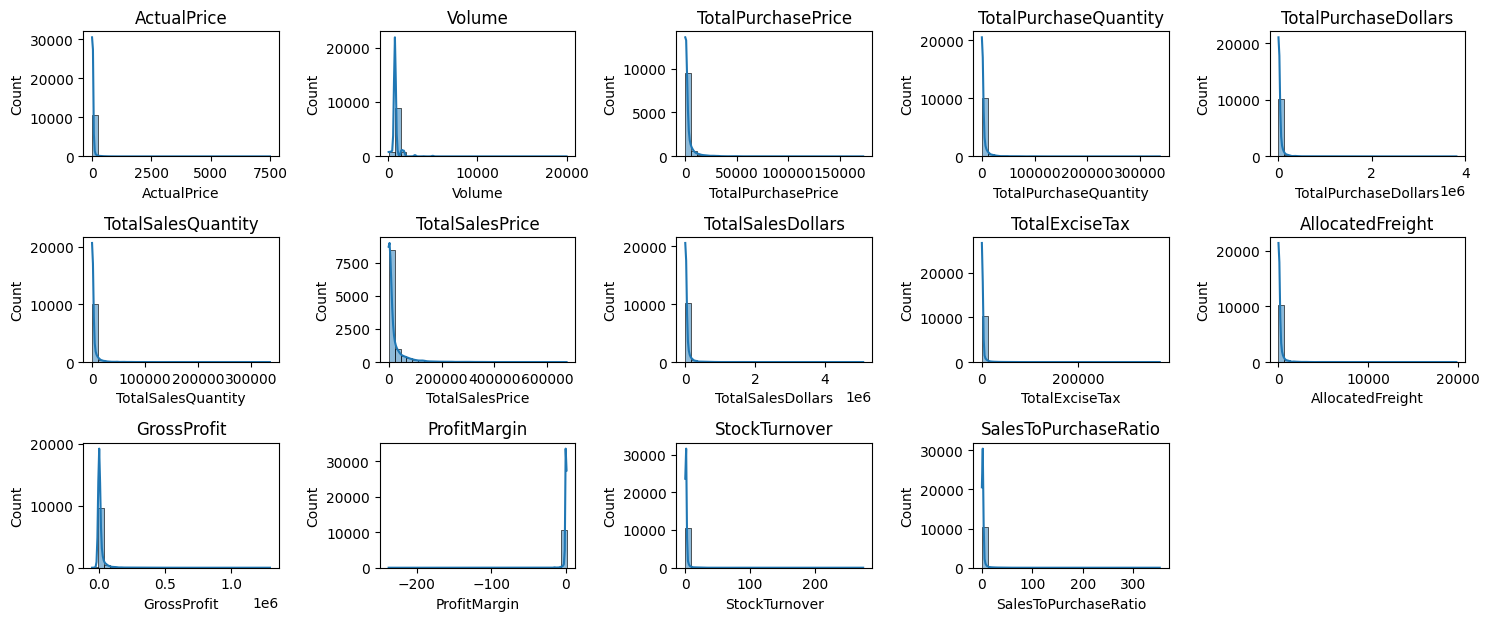

In [10]:
#distibution plots for numerical columns
numerical_cols = df.iloc[:,4:].columns

plt.figure(figsize = (15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(5,5,1+i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

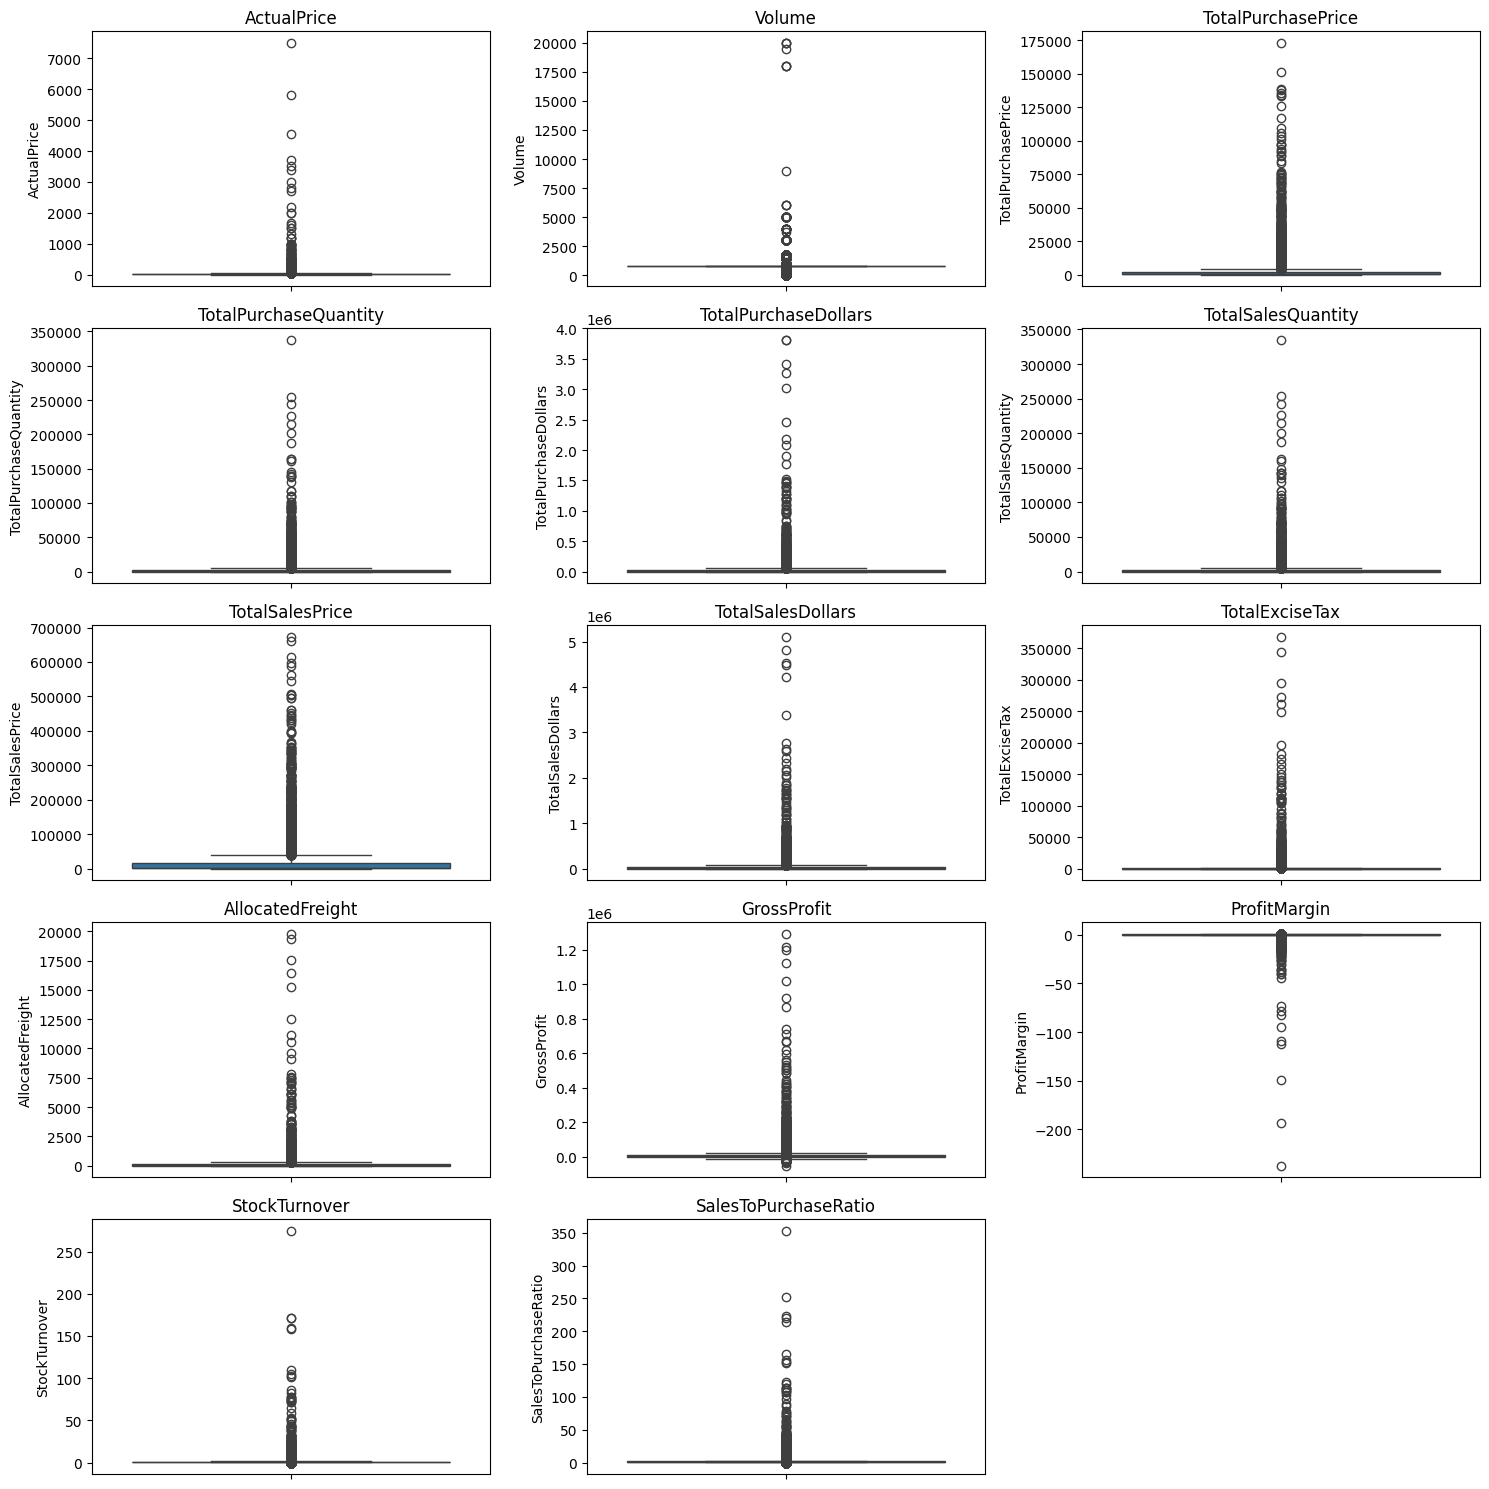

In [11]:
#distibution plots for numerical columns
numerical_cols = df.iloc[:,4:].columns

plt.figure(figsize = (15, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(5,3,1+i)
    sns.boxplot(df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## Summary Statistics Insights:
**Negative & Zero Values:**
- `Gross Profit:` Minimum value is -52,002.78, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price.
- `Profit Margin:` Has a minimum of 0, which suggests cases where revenue is zero or even lower than costs.
- `Total Sales Quantity & Sales Dollars:` Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete
stock.

**Outliers Indicated by High Standard Deviations:**

- `Purchase & Actual Prices:` The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium
products.
- `Freight Cost:` Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
- `Stock Turnover` Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that
Sold quantity for that product is higher than purchased quantity due to either sales are being fulfilled from older stock.

## Data Cleaning

In [12]:
df = pd.read_sql("""select * 
    from vendor_sales_summary 
    where GrossProfit > 0
    and TotalSalesQuantity > 0
""",conn)

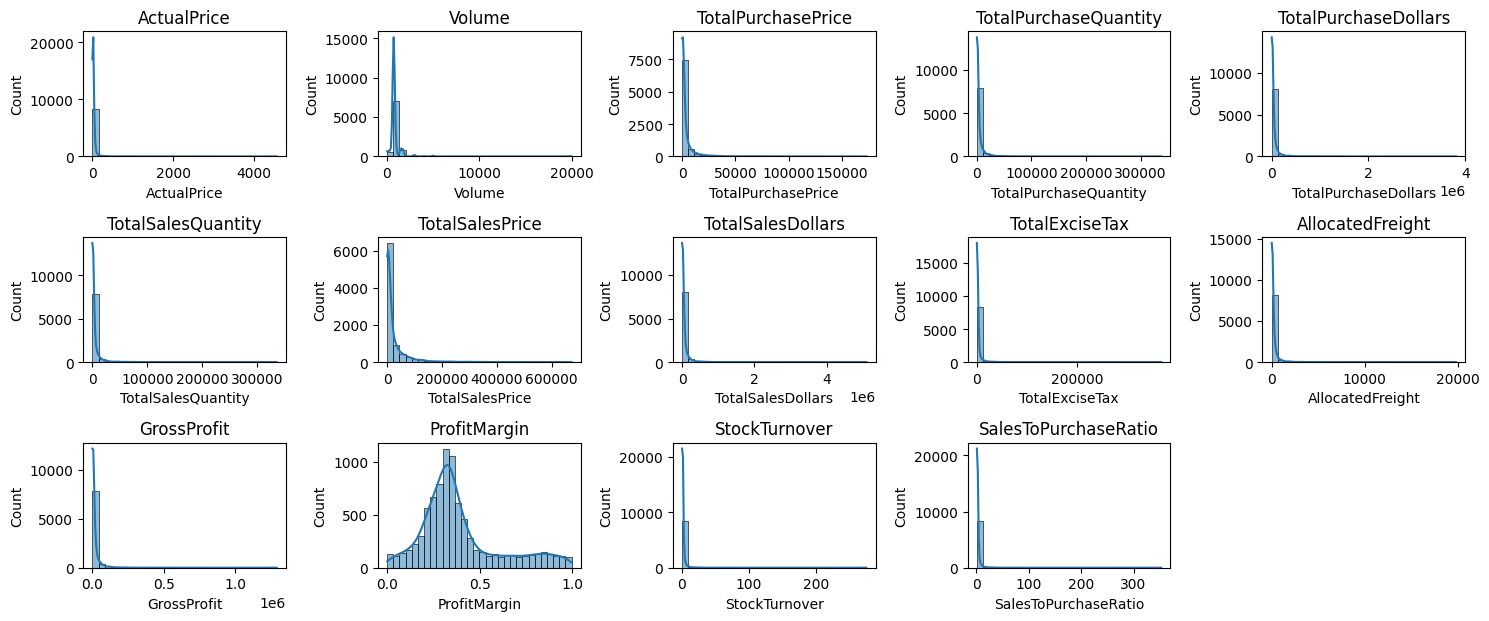

In [13]:
#distibution plots for numerical columns
numerical_cols = df.iloc[:,4:].columns

plt.figure(figsize = (15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(5,5,1+i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

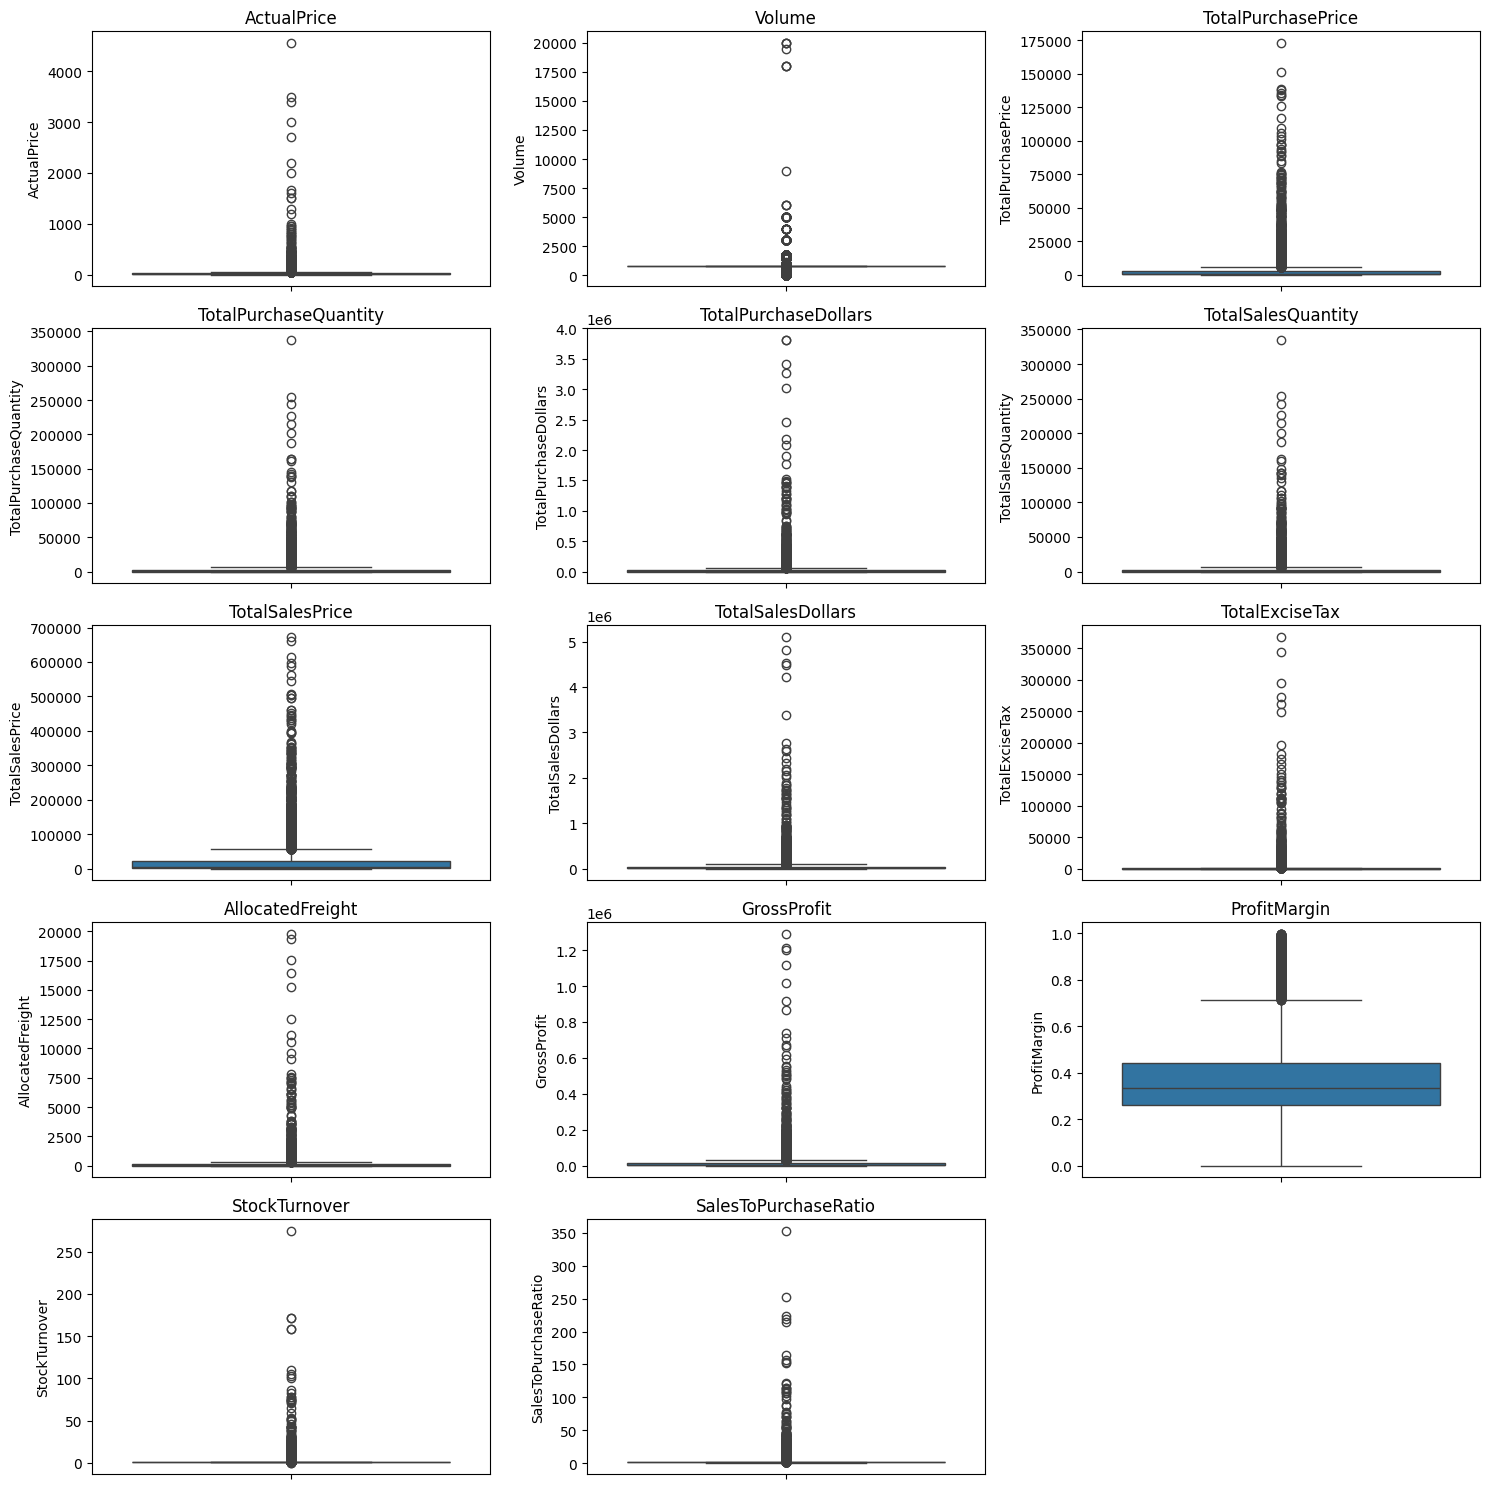

In [14]:
#distibution plots for numerical columns
numerical_cols= df.iloc[:,4:].columns

plt.figure(figsize = (15, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(5,3,1+i)
    sns.boxplot(df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

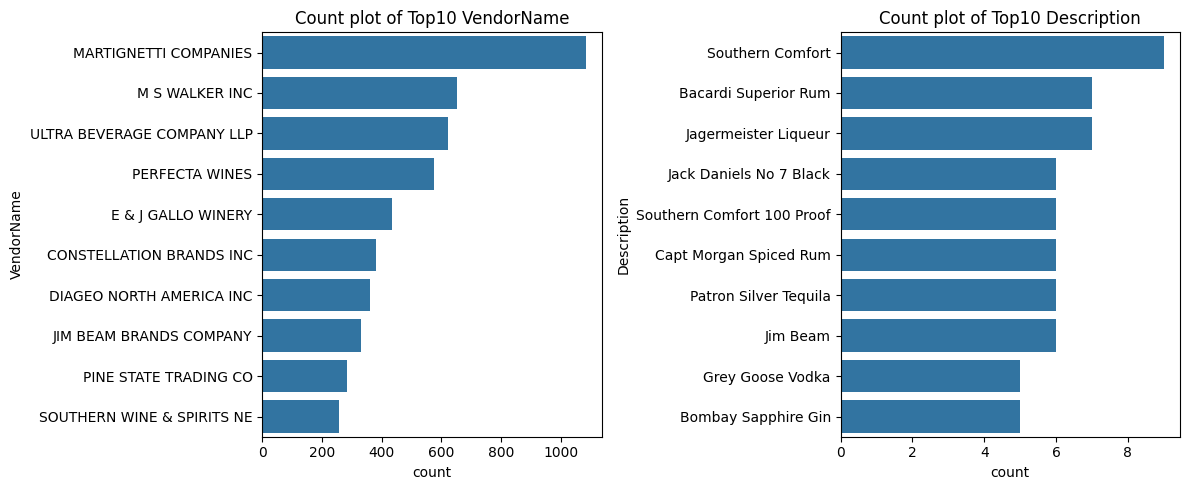

In [15]:
categorical_cols = ['VendorName', 'Description']

plt.figure(figsize=(12,5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1,2,1+i)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10])
    plt.title(f"Count plot of Top10 {col}")
plt.tight_layout()
plt.show()

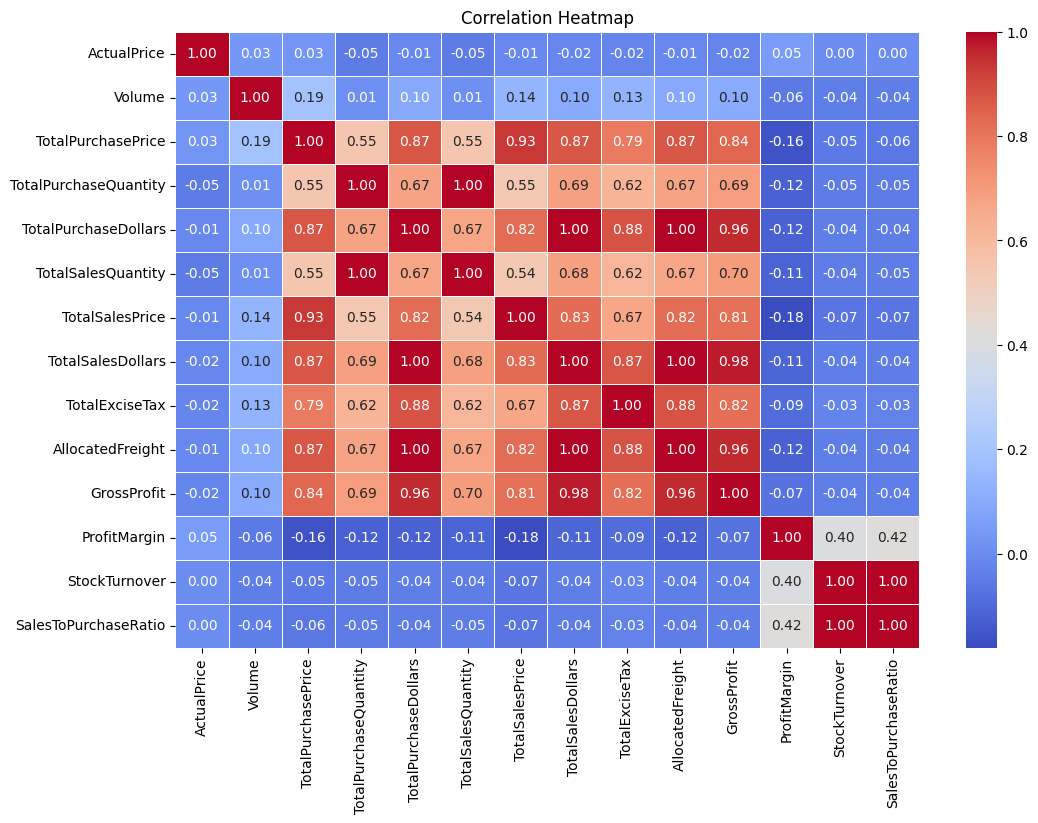

In [64]:
#heatmap
plt.figure(figsize=(12,8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidth=0.5)
plt.title("Correlation Heatmap")
plt.show()

**Correlation Insights**

- `PurchasePrice` has weak correlations with `TotalSalesDollars` (-0.012) and `GrossProfit` (-0.016), suggesting that price variations do not significantly impact sales revenue or profit.
- Strong correlation between TotalPurchaseQuntity and `TotalSlesQuntity` (0.999), confirming efficient inventory turnover.
- Negative correlation between `ProfitMargin` & `TotalSalesPrice` (-0.179) suggests that as sales price increases, margins decrease, possibly due to competitive pricing pressures.
- `StockTurnover` has weak negative correlations with both `GrossProfit` (-0.038) and `ProfitMargin` (-0.055), indicating that faster turnover does not necessarily result in higher profitability.

# Data Analysis

**1. Identify Brands that need promotionl or pricing adjustments which exhibit lower sales performance but higher profit margins.**

In [17]:
brand_performance = df.groupby("Description").agg({'TotalSalesDollars':'sum','ProfitMargin':'mean'}).reset_index()
brand_performance

,Description,TotalSalesDollars,ProfitMargin
0,(RI) 1,21519.09,0.180607
1,.nparalleled Svgn Blanc,1094.63,0.299782
2,10 Span Cab Svgn CC,2703.89,0.209376
3,10 Span Chard CC,3325.56,0.278064
4,10 Span Pnt Gris Monterey Cy,2082.22,0.322262
...,...,...,...
7702,Zorvino Vyds Sangiovese,10579.03,0.295257
7703,Zuccardi Q Malbec,1639.18,0.239815
7704,Zum Rsl,10857.34,0.326750
7705,Zwack Liqueur,227.88,0.166535


In [18]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [20]:
low_sales_threshold

np.float64(560.299)

In [19]:
target_brands = brand_performance[
     (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
     (brand_performance['ProfitMargin'] >= high_margin_threshold)]
print("Brand with low Sales but high Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brand with low Sales but high Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,0.664665
2369,Debauchery Pnt Nr,11.58,0.659758
2070,Concannon Glen Ellen Wh Zin,15.95,0.834483
2188,Crown Royal Apple,27.86,0.898062
6237,Sauza Sprklg Wild Berry Marg,27.96,0.821531
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,0.767473
2271,Dad's Hat Rye Whiskey,538.89,0.818516
57,A Bichot Clos Marechaudes,539.94,0.677409
6245,Sbragia Home Ranch Merlot,549.75,0.664447


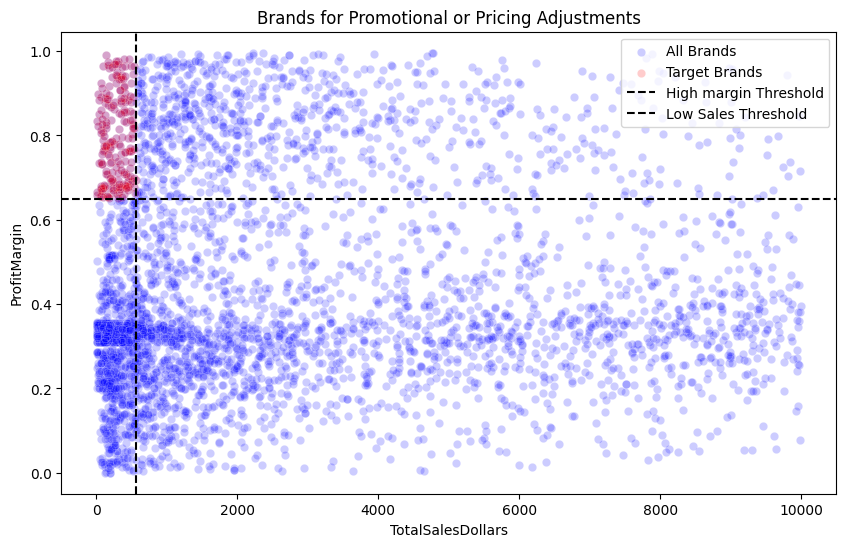

In [21]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='TotalSalesDollars', y='ProfitMargin', data=brand_performance[brand_performance['TotalSalesDollars'] <10000], color='blue', label='All Brands', alpha=0.2)
sns.scatterplot(x='TotalSalesDollars', y='ProfitMargin', data=target_brands, color='red', label='Target Brands', alpha=0.2)

plt.axhline(high_margin_threshold, linestyle='--', color='black', label='High margin Threshold')
plt.axvline(low_sales_threshold, linestyle='--', color='black', label='Low Sales Threshold')

plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.show()

**2. Which vendor and brands demonstrate the highes sales performance?**

In [70]:
# top 10 vendors and brands
top_vendors = df.groupby('VendorName')['TotalSalesDollars'].sum().nlargest(10)
top_brands = df.groupby('Description')['TotalSalesDollars'].sum().nlargest(10)

In [71]:
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      67993304.29
MARTIGNETTI COMPANIES         39317984.69
PERNOD RICARD USA             32048174.93
JIM BEAM BRANDS COMPANY       31405403.96
BACARDI USA INC               24854817.14
CONSTELLATION BRANDS INC      24218745.65
E & J GALLO WINERY            18376296.61
BROWN-FORMAN CORP             18247230.65
ULTRA BEVERAGE COMPANY LLP    16509694.62
M S WALKER INC                14711327.18
Name: TotalSalesDollars, dtype: float64

In [72]:
top_brands

Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollars, dtype: float64

In [73]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value/1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value/1_000:.2f}K"
    else:
        return str(value)
        

In [74]:
top_brands.apply(lambda x : format_dollars(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: str

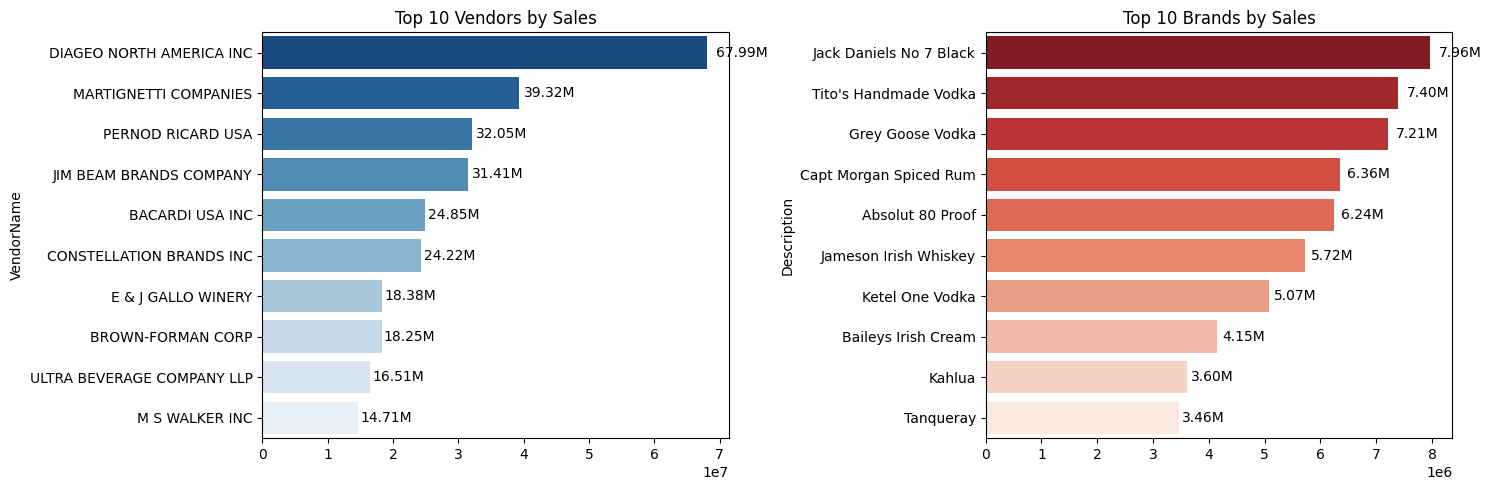

In [75]:
plt.figure(figsize=(15,5))

#top vendors
plt.subplot(1,2,1)
ax1 = sns.barplot(x=top_vendors.values, y=top_vendors.index, palette='Blues_r')
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height()/2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

#top brands
plt.subplot(1,2,2)
ax2 = sns.barplot(x=top_brands.values, y=top_brands.index, palette='Reds_r')
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height()/2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

**3.Which vendors contribute the most to total purchase dollars?**

In [76]:
vendor_performance= df.groupby('VendorName')[['TotalPurchaseDollars', 'GrossProfit', 'TotalSalesDollars']].sum().reset_index()

In [77]:
vendor_performance['PurchaseContribution%'] = vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum()

In [78]:
vendor_performance = round(vendor_performance.sort_values('PurchaseContribution%', ascending=False),2)

In [87]:
#formatting 
top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)

In [88]:
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
26,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,0.16
60,MARTIGNETTI COMPANIES,25.50M,13.82M,39.32M,0.08
71,PERNOD RICARD USA,23.84M,8.21M,32.05M,0.08
47,JIM BEAM BRANDS COMPANY,23.48M,7.92M,31.41M,0.08
6,BACARDI USA INC,17.43M,7.42M,24.85M,0.06
21,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,0.05
12,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,0.04
31,E & J GALLO WINERY,12.06M,6.32M,18.38M,0.04
111,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.51M,0.04
82,SAZERAC CO INC,9.95M,3.43M,13.38M,0.03


In [89]:
top_vendors['Cumulative_contribution'] = top_vendors['PurchaseContribution%'].cumsum()

In [90]:
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_contribution
26,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,0.16,0.16
60,MARTIGNETTI COMPANIES,25.50M,13.82M,39.32M,0.08,0.24
71,PERNOD RICARD USA,23.84M,8.21M,32.05M,0.08,0.32
47,JIM BEAM BRANDS COMPANY,23.48M,7.92M,31.41M,0.08,0.40
6,BACARDI USA INC,17.43M,7.42M,24.85M,0.06,0.46
21,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,0.05,0.51
12,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,0.04,0.55
31,E & J GALLO WINERY,12.06M,6.32M,18.38M,0.04,0.59
111,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.51M,0.04,0.63
82,SAZERAC CO INC,9.95M,3.43M,13.38M,0.03,0.66


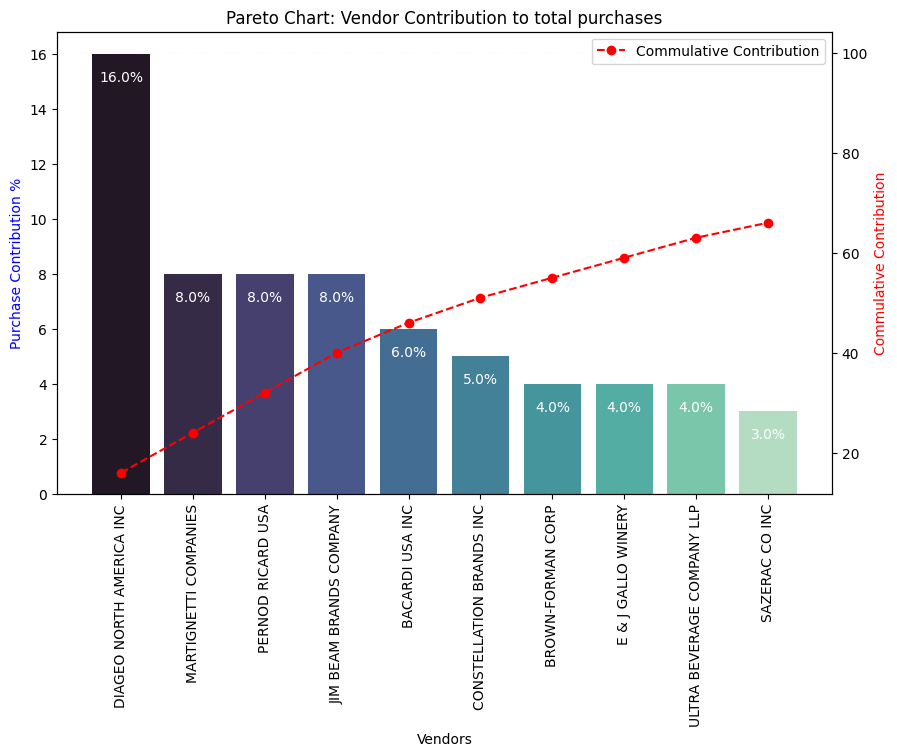

In [91]:
fig, ax1 = plt.subplots(figsize=(10, 6))

#Bar plot for purchase contribution
sns.barplot(x=top_vendors['VendorName'],  y=top_vendors['PurchaseContribution%']*100, palette='mako', ax=ax1)

for i, value in enumerate(top_vendors['PurchaseContribution%']*100):
    ax1.text(i, value - 1, str(value)+"%", ha='center', fontsize=10, color='white')

#line plot for comultive contribution
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'],  top_vendors['Cumulative_contribution']*100, color='red', marker='o', linestyle='--', label='Commulative Contribution')

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel("Purchase Contribution %", color='blue')
ax2.set_ylabel("Commulative Contribution", color='red')
ax1.set_xlabel("Vendors")
ax1.set_title("Pareto Chart: Vendor Contribution to total purchases")

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.01)
ax2.legend(loc='upper right')

plt.show()   

**4. How much of total procurement is dependent on the top vendors?**

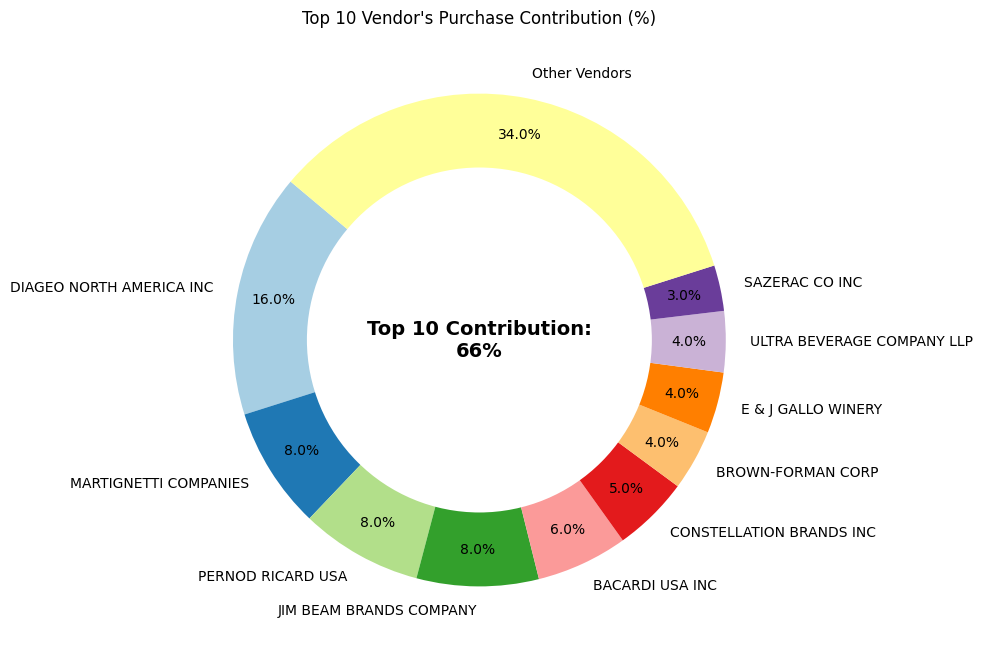

In [92]:
vendors = list(top_vendors ['VendorName' ].values)
purchase_contributions = list(top_vendors['PurchaseContribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 1 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(purchase_contributions, labels=vendors, autopct='%1.1f%%',
                                  startangle=140, pctdistance=0.85, colors=plt.cm.Paired.colors)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(0, 0, f"Top 10 Contribution:\n{total_contribution*100:.0f}%", fontsize=14, fontweight='bold', ha='center', va='center')
plt.title("Top 10 Vendor's Purchase Contribution (%)")

plt.show()

**5. Does purchasing in bulk reduce the unit price, and what is the optimal purchase vlume for cost savings?**

In [93]:
df['UnitPurchasePrice']=df['TotalPurchaseDollars']/df['TotalPurchaseQuantity']

In [94]:
df

,VendorNumber,VendorName,Brand,Description,ActualPrice,Volume,TotalPurchasePrice,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,...,TotalSalesDollars,TotalExciseTax,AllocatedFreight,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio,UnitPurchasePrice,OrderSize,UnsoldInventoryValue
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,36.99,750.0,71.58,8,190.88,18.0,...,665.82,2.00,0.917979,474.94,0.713316,2.250000,3.488160,23.86,Small,-238.60
1,60,ADAMBA IMPORTS INTL INC,771,Bak's Krupnik Honey Liqueur,14.99,750.0,45.76,39,446.16,47.0,...,704.53,37.01,2.135889,258.37,0.366727,1.205128,1.579097,11.44,Small,-91.52
2,105,ALTAMAR BRANDS LLC,2529,Right Gin,29.99,750.0,46.50,12,279.00,12.0,...,359.88,9.44,1.486974,80.88,0.224742,1.000000,1.289892,23.25,Small,0.00
3,105,ALTAMAR BRANDS LLC,8412,Tequila Ocho Plata Fresno,49.99,750.0,1964.05,320,11427.20,307.0,...,15346.93,242.15,60.903026,3919.73,0.255408,0.959375,1.343018,35.71,Medium,464.23
4,200,AMERICAN SPIRITS EXCHANGE,20789,Zin-phomaniac Znfdl,14.99,750.0,58.38,96,934.08,84.0,...,1511.16,9.43,4.797666,577.08,0.381879,0.875000,1.617806,9.73,Medium,116.76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,172662,STARK BREWING COMPANY,2191,Clark & Chesterfield Whiskey,19.99,375.0,161.70,138,2028.60,125.0,...,2498.75,49.00,10.423540,470.15,0.188154,0.905797,1.231761,14.70,Medium,191.10
8560,172662,SWEETWATER FARM,2265,Monadnock Moonshine,28.99,750.0,450.87,267,5732.49,222.0,...,6435.78,175.13,29.455209,703.29,0.109278,0.831461,1.122685,21.47,Medium,966.15
8561,172662,SWEETWATER FARM,3632,Ashuelot Vodka,28.49,750.0,992.68,554,11955.32,452.0,...,12877.48,356.14,61.429928,922.16,0.071610,0.815884,1.077134,21.58,Medium,2201.16
8562,173357,TAMWORTH DISTILLING,3909,White Mountain Vodka,24.99,750.0,1762.67,1232,23863.84,982.0,...,24540.18,773.87,117.759426,676.34,0.027561,0.797078,1.028342,19.37,Medium,4842.50


In [95]:
df['OrderSize'] = pd.qcut(df['TotalPurchaseQuantity'], q=3, labels=['Small', 'Medium', 'Large'])

In [101]:
df.groupby("OrderSize")['UnitPurchasePrice'].mean()

OrderSize
Small     39.068186
Medium    15.486414
Large     10.777625
Name: UnitPurchasePrice, dtype: float64

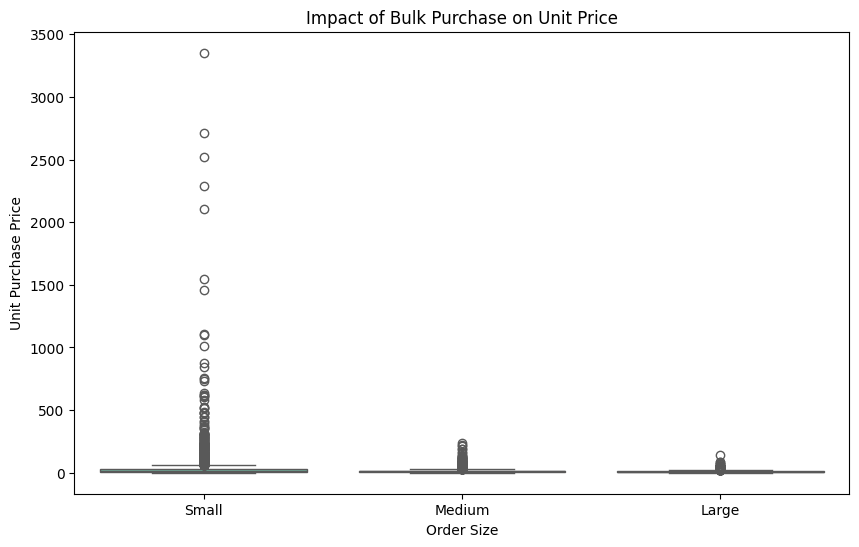

In [102]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x='OrderSize', y='UnitPurchasePrice', palette='Set2')
plt.title("Impact of Bulk Purchase on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Unit Purchase Price")

plt.show()

**Insights**
  
- Vendors buying in bulk (Large Order Size) get the lowest unit price ($10.78 per unit), meaning higher margins if they can manage inventory efficiently.
- The price difference between Small and Large orders is substantial (~72% reduction in unit cost)
- This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes, leading to higher overall sales despite lower per-unit
revenue.

**6. Which Vendor have low inventory turnover, indicating over stock and slow-moving products?**

In [103]:
df[df['StockTurnover'] < 1].groupby('VendorName')['StockTurnover'].mean().reset_index('VendorName').sort_values('StockTurnover').head(10)

,VendorName,StockTurnover
0,ALISA CARR BEVERAGES,0.615385
26,Dunn Wine Brokers,0.752301
19,Circa Wines,0.755676
41,KLIN SPIRITS LLC,0.763889
80,SMOKY QUARTZ DISTILLERY LLC,0.783835
94,TAMWORTH DISTILLING,0.797078
105,WALPOLE MTN VIEW WINERY,0.801529
95,THE IMPORTED GRAPE LLC,0.814770
15,CENTEUR IMPORTS LLC,0.816653
8,BRONCO WINE COMPANY,0.822601


**7. How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it?**

In [104]:
df['UnsoldInventoryValue'] = (df['TotalPurchaseQuantity'] - df['TotalSalesQuantity']) * df['UnitPurchasePrice']

In [105]:
# Totall capital locked per vendor
inventory_value_per_vendor = df.groupby('VendorName')['UnsoldInventoryValue'].sum().reset_index()

inventory_value_per_vendor = inventory_value_per_vendor.sort_values('UnsoldInventoryValue', ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
26,DIAGEO NORTH AMERICA INC,724.89K
47,JIM BEAM BRANDS COMPANY,555.92K
71,PERNOD RICARD USA,468.08K
120,WILLIAM GRANT & SONS INC,401.91K
31,E & J GALLO WINERY,233.71K
82,SAZERAC CO INC,216.90K
12,BROWN-FORMAN CORP,177.73K
21,CONSTELLATION BRANDS INC,133.62K
80,REMY COINTREAU USA INC,112.20K
64,MOET HENNESSY USA INC,107.99K


**8. What is the 95% confidence intervals for the profit margins of top performaing and low performing vendors.**

In [45]:
top_threshold = df['TotalSalesDollars'].quantile(0.75)
low_threshold = df['TotalSalesDollars'].quantile(0.25)



In [46]:
top_performers = df[df["TotalSalesDollars"] >= top_threshold]['ProfitMargin'].dropna()
low_performers = df[df["TotalSalesDollars"] <= low_threshold]['ProfitMargin'].dropna()



In [47]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1)/np.sqrt(len(data))
    t_critical = stats.t.ppf((1 + confidence)/2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (0.31, 0.32), Mean: 0.31
Low lendors 95% CI: (0.41, 0.43), Mean: 0.42


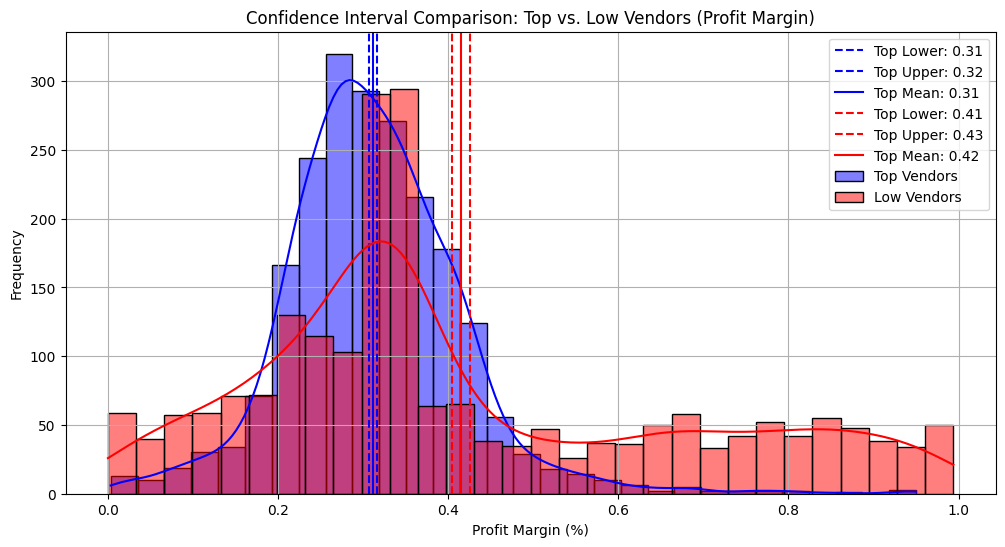

In [48]:
top_mean, top_lower, top_upper = confidence_interval(top_performers)
low_mean, low_lower, low_upper = confidence_interval(low_performers)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low lendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_performers, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_performers, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Top Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Top Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Top Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

plt.show()

**Insights**

- The confidence interval for low-performing vendors (41% to 43%) is significantly higher than that of top-performing vendors (31% to 32%).
- This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs.
- For High-Perfarming Vendars: If they aim to improve profitability, they could explore selective price adjustments, cost optimization, or bundling strategies.
- For Low-Performing Vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distribution strategies.

**9. Is there any significant difference in profit margins between top performing vendors and low performing vendprs?**

Hypothesis:

- `H0 (null hypothesis)`: There is no significant difference in mean profit margins of top performing and low performing vendors.
- `H1 (alternative hypothesis)`: The mean profit margins of top performing and low performing vendors are significantly different.

In [52]:
from scipy.stats import ttest_ind

# T-test
t_stat, p_value = ttest_ind(top_performers, low_performers, equal_var=False)

print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject Ho, There is signinficant difference in profit margins between the top and low performing vendors.")
else:
    print("Fail to reject Ho: No significant difference in profit margins")

T-Statistic: -17.6695, P-Value: 0.0000
Reject Ho, There is signinficant difference in profit margins between the top and low performing vendors.
